In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

os.listdir(PROJECT_PATH)


['1st Raw_Dataset',
 '2nd Data_Verification',
 '3rd Preprocessing',
 '4th Model_Training',
 '5th Model_Evaluation',
 '6th Trained_Model',
 '7th Test_Images',
 '8th Web_Application',
 '9th Documentation',
 '10th Presentation PPT']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

print(os.listdir(BASE_PATH))

['1st Raw_Dataset', '2nd Data_Verification', '3rd Preprocessing', '4th Model_Training', '5th Model_Evaluation', '6th Trained_Model', '7th Test_Images', '8th Web_Application', '9th Documentation', '10th Presentation PPT']


In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import userdata

KAGGLE_API_TOKEN = userdata.get('KAGGLE_API_TOKEN')

if KAGGLE_API_TOKEN:
    print("✅ Kaggle token connected!")
else:
    print("❌ Token not found")

✅ Kaggle token connected!


In [ ]:
!mkdir -p /content/plantdisease

In [ ]:
!kaggle datasets download -d emmarex/plantdisease -p /content/plantdisease


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 141MB/s]



In [ ]:
import os

print(os.listdir("/content/plantdisease"))

['plantdisease.zip']


In [ ]:
import zipfile

ZIP_PATH = "/content/plantdisease/plantdisease.zip"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    files = zip_ref.namelist()

print("Total files:", len(files))

# Top-level folders/classes
folders = sorted(set(
    f.split('/')[1]
    for f in files
    if '/' in f and f.split('/')[0] == "PlantVillage"
))

print("\nAll classes/folders:")
for folder in folders:
    print(folder)


Total files: 41278

All classes/folders:
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [ ]:
potato_files = [f for f in files if "Potato" in f]

print("Total Potato files:", len(potato_files))

potato_classes = sorted(set(
    f.split('/')[1]
    for f in potato_files
    if '/' in f
))

print("\nPotato classes:")
for cls in potato_classes:
    print(cls)

Total Potato files: 4304

Potato classes:
PlantVillage
Potato___Early_blight
Potato___Late_blight
Potato___healthy


In [ ]:
from collections import Counter

potato_images = [
    f for f in files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
    and any(cls in f for cls in [
        "Potato___Early_blight",
        "Potato___Late_blight",
        "Potato___healthy"
    ])
]

counts = Counter(
    f.split("/")[1]
    for f in potato_images
)

print("Total Potato images:", len(potato_images))

print("\nClass-wise count:")
for cls, count in counts.items():
    print(cls, ":", count)

Total Potato images: 4304

Class-wise count:
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152
PlantVillage : 2152


In [ ]:
# Show 20 actual Potato file paths
potato_paths = [
    f for f in unique_files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
    and "Potato___" in f
]

print("First 20 Potato paths:\n")

for f in potato_paths[:20]:
    print(f)

First 20 Potato paths:

PlantVillage/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG
PlantVillage/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG
PlantVillage/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG
PlantVillage/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG
PlantVillage/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG
PlantVillage/Potato___Early_blight/02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Early.B 7562.JPG
PlantVillage/Potato___Early_blight/0267d4ca-522e-4ca0-b1a2-ce925e5b54a2___RS_Early.B 7020.JPG
PlantVillage/Potato___Early_blight/028f9b73-142f-499a-9c7b-d7c1ed5e5506___RS_Early.B 8546.JPG
PlantVillage/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136.JPG
PlantVillage/Potato___Early_blight/03b0d3c1-b5b0-48f4-98aa-f8904670290f___RS_Early.B 7051.JPG
PlantVillage/Potato___Early_blight/0

In [ ]:
# See how many images exist for each complete folder/path
from collections import Counter

folder_counts = Counter()

for f in potato_paths:
    parts = f.split("/")

    # Find the Potato class folder
    for i, part in enumerate(parts):
        if part.startswith("Potato___"):
            folder_counts["/".join(parts[:i+1])] += 1
            break

print("Potato folder paths:\n")

for folder, count in sorted(folder_counts.items()):
    print(count, "->", folder)

Potato folder paths:

1000 -> PlantVillage/Potato___Early_blight
1000 -> PlantVillage/Potato___Late_blight
152 -> PlantVillage/Potato___healthy
1000 -> plantvillage/PlantVillage/Potato___Early_blight
1000 -> plantvillage/PlantVillage/Potato___Late_blight
152 -> plantvillage/PlantVillage/Potato___healthy


In [ ]:
selected_potato = [
    f for f in unique_files
    if f.startswith("PlantVillage/Potato___")
    and f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Selected Potato images:", len(selected_potato))

from collections import Counter

counts = Counter(f.split("/")[1] for f in selected_potato)

for cls, count in sorted(counts.items()):
    print(cls, ":", count)


Selected Potato images: 2152
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152


In [ ]:
import os
import zipfile
import shutil

ZIP_PATH = "/content/plantdisease/plantdisease.zip"

DRIVE_BASE = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
RAW_PATH = os.path.join(DRIVE_BASE, "1st Raw_Dataset", "Potato")

classes = {
    "Potato___healthy": "Healthy",
    "Potato___Early_blight": "Early_Blight",
    "Potato___Late_blight": "Late_Blight"
}

# Create destination folders
for destination in classes.values():
    os.makedirs(os.path.join(RAW_PATH, destination), exist_ok=True)

# Extract only ONE verified copy
copied = {name: 0 for name in classes.values()}

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for file_path in z.namelist():

        # Only use the verified PlantVillage copy
        if not file_path.startswith("PlantVillage/"):
            continue

        if not file_path.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        for source_class, destination_class in classes.items():

            if f"PlantVillage/{source_class}/" in file_path:

                filename = os.path.basename(file_path)

                destination_path = os.path.join(
                    RAW_PATH,
                    destination_class,
                    filename
                )

                with z.open(file_path) as source, open(destination_path, "wb") as target:
                    shutil.copyfileobj(source, target)

                copied[destination_class] += 1
                break

print("✅ Selected Potato dataset copied successfully!\n")

for cls, count in copied.items():
    print(f"{cls}: {count}")

print("TOTAL:", sum(copied.values()))

✅ Selected Potato dataset copied successfully!

Healthy: 152
Early_Blight: 1000
Late_Blight: 1000
TOTAL: 2152


In [ ]:
import os

RAW_PATH = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/1st Raw_Dataset/Potato"

for folder in ["Healthy", "Early_Blight", "Late_Blight"]:
    path = os.path.join(RAW_PATH, folder)

    images = [
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{folder}: {len(images)} images")

print("\n✅ Raw dataset verification completed.")

Healthy: 152 images
Early_Blight: 1000 images
Late_Blight: 1000 images

✅ Raw dataset verification completed.


In [ ]:
import os

RAW_PATH = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/1st Raw_Dataset/Potato"

classes = ["Healthy", "Early_Blight", "Late_Blight"]

class_counts = {}

for cls in classes:
    folder = os.path.join(RAW_PATH, cls)
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    class_counts[cls] = len(images)

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal:", sum(class_counts.values()))

Class Distribution:
Healthy: 152
Early_Blight: 1000
Late_Blight: 1000

Total: 2152


In [ ]:
from PIL import Image
from collections import Counter

dimensions = []

for cls in classes:
    folder = os.path.join(RAW_PATH, cls)

    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)

            try:
                with Image.open(path) as img:
                    dimensions.append(img.size)
            except:
                pass

print("Total readable images:", len(dimensions))

print("\nMost common image dimensions:")
for size, count in Counter(dimensions).most_common(10):
    print(size, ":", count)

Total readable images: 2152

Most common image dimensions:
(256, 256) : 2152


In [ ]:
corrupted = []

for cls in classes:
    folder = os.path.join(RAW_PATH, cls)

    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)

            try:
                with Image.open(path) as img:
                    img.verify()
            except:
                corrupted.append(path)

print("Corrupted/unreadable images:", len(corrupted))

if len(corrupted) == 0:
    print("✅ All images are readable.")
else:
    print("⚠️ Corrupted files found:")
    for file in corrupted[:10]:
        print(file)

Corrupted/unreadable images: 0
✅ All images are readable.


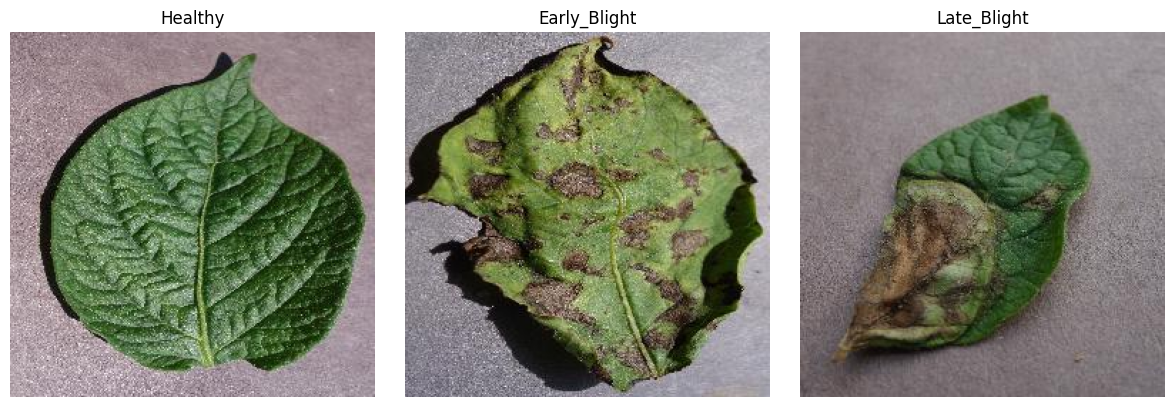

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cls in zip(axes, classes):
    folder = os.path.join(RAW_PATH, cls)

    filename = next(
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    image = Image.open(os.path.join(folder, filename))

    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("========== DATASET VERIFICATION SUMMARY ==========")
print("Dataset: Potato Plant Disease")
print("Total Images:", sum(class_counts.values()))

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("Corrupted Images:", len(corrupted))
print("Readable Images:", len(dimensions))

========== DATASET VERIFICATION SUMMARY ==========
Dataset: Potato Plant Disease
Total Images: 2152
Healthy: 152
Early_Blight: 1000
Late_Blight: 1000
Corrupted Images: 0
Readable Images: 2152
